<a href="https://colab.research.google.com/github/ahsan11777/ML_Full_Course/blob/main/TCGA_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("/content/drive/MyDrive/ML-Course/TCGA_data/brca_count_merged_data.csv", index_col = 0)

In [3]:
df.head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,Unnamed: 60661
TCGA-A2-A25D-01A-12R-A16F-07,4474,9,1785,1362,433,928,2445,4487,2278,2511,...,0,27,0,0,0,150,0,6,21,Primary solid Tumor
TCGA-BH-A201-01A-11R-A14M-07,3555,30,2537,1865,890,711,4352,2175,2472,3796,...,0,38,0,0,0,590,0,11,28,Primary solid Tumor
TCGA-AC-A23C-01A-12R-A169-07,731,113,5947,3118,1063,460,4609,4547,2265,4388,...,3,60,0,0,0,754,0,14,31,Primary solid Tumor
TCGA-AR-A5QP-01A-11R-A28M-07,3960,50,2155,1355,474,237,2440,2270,2637,1914,...,0,18,0,0,0,332,0,9,31,Primary solid Tumor
TCGA-C8-A12P-01A-11R-A115-07,3834,0,3161,1411,637,468,4472,2588,1601,1585,...,0,8,0,0,0,354,0,0,13,Primary solid Tumor


## Label Encoding

In [4]:
df["Unnamed: 60661"].value_counts()

,count
Unnamed: 60661,
Primary solid Tumor,1111
Solid Tissue Normal,113


In [5]:
df.isnull().sum()

,0
ENSG00000000003.15,0
ENSG00000000005.6,0
ENSG00000000419.13,0
ENSG00000000457.14,0
ENSG00000000460.17,0
...,...
ENSG00000288670.1,0
ENSG00000288671.1,0
ENSG00000288674.1,0
ENSG00000288675.1,0


In [6]:
df["Sample_Type"] = df["Unnamed: 60661"]

In [7]:
df.drop("Unnamed: 60661", axis = 1, inplace = True)

In [8]:
df.tail()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,Sample_Type
TCGA-LL-A5YP-01A-21R-A28M-07,2300,7,2524,720,632,491,3520,1620,771,2189,...,0,12,0,0,1,140,0,6,13,Primary solid Tumor
TCGA-AO-A03L-01A-41R-A056-07,955,3,3231,1763,899,324,2690,1887,1235,4038,...,0,21,0,0,0,416,0,9,54,Primary solid Tumor
TCGA-BH-A42T-01A-11R-A24H-07,2641,40,2311,1263,904,744,1078,3328,1359,2826,...,0,42,0,0,0,561,0,57,26,Primary solid Tumor
TCGA-A2-A04W-01A-31R-A115-07,2718,1,1914,677,291,224,1053,2223,703,1271,...,0,9,0,0,0,121,0,1,34,Primary solid Tumor
TCGA-AR-A24O-01A-11R-A169-07,1856,58,2184,1206,574,402,7647,1942,2423,3644,...,0,30,0,0,0,287,0,9,14,Primary solid Tumor


In [9]:
df["Sample_Type"].value_counts()

,count
Sample_Type,
Primary solid Tumor,1111
Solid Tissue Normal,113


In [10]:
labels = {
    "Primary solid Tumor": 1,
    "Solid Tissue Normal": 0
}

In [11]:
df2 = df

In [12]:
df2["Sample_Type"] = df["Sample_Type"].map(labels)
df2.head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,Sample_Type
TCGA-A2-A25D-01A-12R-A16F-07,4474,9,1785,1362,433,928,2445,4487,2278,2511,...,0,27,0,0,0,150,0,6,21,1
TCGA-BH-A201-01A-11R-A14M-07,3555,30,2537,1865,890,711,4352,2175,2472,3796,...,0,38,0,0,0,590,0,11,28,1
TCGA-AC-A23C-01A-12R-A169-07,731,113,5947,3118,1063,460,4609,4547,2265,4388,...,3,60,0,0,0,754,0,14,31,1
TCGA-AR-A5QP-01A-11R-A28M-07,3960,50,2155,1355,474,237,2440,2270,2637,1914,...,0,18,0,0,0,332,0,9,31,1
TCGA-C8-A12P-01A-11R-A115-07,3834,0,3161,1411,637,468,4472,2588,1601,1585,...,0,8,0,0,0,354,0,0,13,1


In [13]:
df2["Sample_Type"].value_counts()

,count
Sample_Type,
1,1111
0,113


In [14]:
df["Sample_Type"].value_counts()

,count
Sample_Type,
1,1111
0,113


In [15]:
df.head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,Sample_Type
TCGA-A2-A25D-01A-12R-A16F-07,4474,9,1785,1362,433,928,2445,4487,2278,2511,...,0,27,0,0,0,150,0,6,21,1
TCGA-BH-A201-01A-11R-A14M-07,3555,30,2537,1865,890,711,4352,2175,2472,3796,...,0,38,0,0,0,590,0,11,28,1
TCGA-AC-A23C-01A-12R-A169-07,731,113,5947,3118,1063,460,4609,4547,2265,4388,...,3,60,0,0,0,754,0,14,31,1
TCGA-AR-A5QP-01A-11R-A28M-07,3960,50,2155,1355,474,237,2440,2270,2637,1914,...,0,18,0,0,0,332,0,9,31,1
TCGA-C8-A12P-01A-11R-A115-07,3834,0,3161,1411,637,468,4472,2588,1601,1585,...,0,8,0,0,0,354,0,0,13,1


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1224 entries, TCGA-A2-A25D-01A-12R-A16F-07 to TCGA-AR-A24O-01A-11R-A169-07
Columns: 60661 entries, ENSG00000000003.15 to Sample_Type
dtypes: int64(60661)
memory usage: 566.5+ MB


In [17]:
df.shape

(1224, 60661)

In [18]:
df.isnull().sum()

,0
ENSG00000000003.15,0
ENSG00000000005.6,0
ENSG00000000419.13,0
ENSG00000000457.14,0
ENSG00000000460.17,0
...,...
ENSG00000288670.1,0
ENSG00000288671.1,0
ENSG00000288674.1,0
ENSG00000288675.1,0


In [19]:
df.isnull().sum().sum()

np.int64(0)

In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1224 entries, TCGA-A2-A25D-01A-12R-A16F-07 to TCGA-AR-A24O-01A-11R-A169-07
Columns: 60661 entries, ENSG00000000003.15 to Sample_Type
dtypes: int64(60661)
memory usage: 566.5+ MB


In [21]:
df.rename(columns={'Unnamed: 60661':'Sample_Type'},inplace=True)

In [22]:
df.head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,Sample_Type
TCGA-A2-A25D-01A-12R-A16F-07,4474,9,1785,1362,433,928,2445,4487,2278,2511,...,0,27,0,0,0,150,0,6,21,1
TCGA-BH-A201-01A-11R-A14M-07,3555,30,2537,1865,890,711,4352,2175,2472,3796,...,0,38,0,0,0,590,0,11,28,1
TCGA-AC-A23C-01A-12R-A169-07,731,113,5947,3118,1063,460,4609,4547,2265,4388,...,3,60,0,0,0,754,0,14,31,1
TCGA-AR-A5QP-01A-11R-A28M-07,3960,50,2155,1355,474,237,2440,2270,2637,1914,...,0,18,0,0,0,332,0,9,31,1
TCGA-C8-A12P-01A-11R-A115-07,3834,0,3161,1411,637,468,4472,2588,1601,1585,...,0,8,0,0,0,354,0,0,13,1


In [23]:
df["Sample_Type"]

,Sample_Type
TCGA-A2-A25D-01A-12R-A16F-07,1
TCGA-BH-A201-01A-11R-A14M-07,1
TCGA-AC-A23C-01A-12R-A169-07,1
TCGA-AR-A5QP-01A-11R-A28M-07,1
TCGA-C8-A12P-01A-11R-A115-07,1
...,...
TCGA-LL-A5YP-01A-21R-A28M-07,1
TCGA-AO-A03L-01A-41R-A056-07,1
TCGA-BH-A42T-01A-11R-A24H-07,1
TCGA-A2-A04W-01A-31R-A115-07,1


In [24]:
df["Sample_Type"].value_counts()

,count
Sample_Type,
1,1111
0,113


In [25]:
df.head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,Sample_Type
TCGA-A2-A25D-01A-12R-A16F-07,4474,9,1785,1362,433,928,2445,4487,2278,2511,...,0,27,0,0,0,150,0,6,21,1
TCGA-BH-A201-01A-11R-A14M-07,3555,30,2537,1865,890,711,4352,2175,2472,3796,...,0,38,0,0,0,590,0,11,28,1
TCGA-AC-A23C-01A-12R-A169-07,731,113,5947,3118,1063,460,4609,4547,2265,4388,...,3,60,0,0,0,754,0,14,31,1
TCGA-AR-A5QP-01A-11R-A28M-07,3960,50,2155,1355,474,237,2440,2270,2637,1914,...,0,18,0,0,0,332,0,9,31,1
TCGA-C8-A12P-01A-11R-A115-07,3834,0,3161,1411,637,468,4472,2588,1601,1585,...,0,8,0,0,0,354,0,0,13,1


# Things to do now
1. Seperate X and y
2. Normalize X
3. Apply PCA on X
4. Take pca result
5. Apply Train - Test Split on pca data 70-30 (stratify by y)
6. Apply balencing technie on training data e.g. SMOTEN
7. Train Models e.g. SVM
8. Visualize model performences

## Data Seperation X and y

In [26]:
df["Sample_Type"].value_counts()

,count
Sample_Type,
1,1111
0,113


In [27]:
df.columns

Index(['ENSG00000000003.15', 'ENSG00000000005.6', 'ENSG00000000419.13',
       'ENSG00000000457.14', 'ENSG00000000460.17', 'ENSG00000000938.13',
       'ENSG00000000971.16', 'ENSG00000001036.14', 'ENSG00000001084.13',
       'ENSG00000001167.14',
       ...
       'ENSG00000288662.1', 'ENSG00000288663.1', 'ENSG00000288665.1',
       'ENSG00000288667.1', 'ENSG00000288669.1', 'ENSG00000288670.1',
       'ENSG00000288671.1', 'ENSG00000288674.1', 'ENSG00000288675.1',
       'Sample_Type'],
      dtype='object', length=60661)

In [28]:
# data_only_sample_type_column = df["Sample_Type"]

X = df.drop("Sample_Type", axis = 1)
y = df["Sample_Type"]

In [29]:
y.value_counts()

,count
Sample_Type,
1,1111
0,113


In [30]:
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (1224, 60660)
Shape of y: (1224,)


In [31]:
X.head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-A2-A25D-01A-12R-A16F-07,4474,9,1785,1362,433,928,2445,4487,2278,2511,...,0,0,27,0,0,0,150,0,6,21
TCGA-BH-A201-01A-11R-A14M-07,3555,30,2537,1865,890,711,4352,2175,2472,3796,...,0,0,38,0,0,0,590,0,11,28
TCGA-AC-A23C-01A-12R-A169-07,731,113,5947,3118,1063,460,4609,4547,2265,4388,...,0,3,60,0,0,0,754,0,14,31
TCGA-AR-A5QP-01A-11R-A28M-07,3960,50,2155,1355,474,237,2440,2270,2637,1914,...,0,0,18,0,0,0,332,0,9,31
TCGA-C8-A12P-01A-11R-A115-07,3834,0,3161,1411,637,468,4472,2588,1601,1585,...,0,0,8,0,0,0,354,0,0,13


## Normalize X

In [32]:
df2.head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,Sample_Type
TCGA-A2-A25D-01A-12R-A16F-07,4474,9,1785,1362,433,928,2445,4487,2278,2511,...,0,27,0,0,0,150,0,6,21,1
TCGA-BH-A201-01A-11R-A14M-07,3555,30,2537,1865,890,711,4352,2175,2472,3796,...,0,38,0,0,0,590,0,11,28,1
TCGA-AC-A23C-01A-12R-A169-07,731,113,5947,3118,1063,460,4609,4547,2265,4388,...,3,60,0,0,0,754,0,14,31,1
TCGA-AR-A5QP-01A-11R-A28M-07,3960,50,2155,1355,474,237,2440,2270,2637,1914,...,0,18,0,0,0,332,0,9,31,1
TCGA-C8-A12P-01A-11R-A115-07,3834,0,3161,1411,637,468,4472,2588,1601,1585,...,0,8,0,0,0,354,0,0,13,1


In [33]:
from sklearn.preprocessing import MinMaxScaler

In [34]:
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

In [35]:
X_norm[:2]

array([[0.10789493, 0.00039609, 0.08535667, ..., 0.        , 0.10526316,
        0.03271028],
       [0.08531341, 0.00132031, 0.12893319, ..., 0.        , 0.19298246,
        0.04361371]])

In [36]:
X.head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-A2-A25D-01A-12R-A16F-07,4474,9,1785,1362,433,928,2445,4487,2278,2511,...,0,0,27,0,0,0,150,0,6,21
TCGA-BH-A201-01A-11R-A14M-07,3555,30,2537,1865,890,711,4352,2175,2472,3796,...,0,0,38,0,0,0,590,0,11,28
TCGA-AC-A23C-01A-12R-A169-07,731,113,5947,3118,1063,460,4609,4547,2265,4388,...,0,3,60,0,0,0,754,0,14,31
TCGA-AR-A5QP-01A-11R-A28M-07,3960,50,2155,1355,474,237,2440,2270,2637,1914,...,0,0,18,0,0,0,332,0,9,31
TCGA-C8-A12P-01A-11R-A115-07,3834,0,3161,1411,637,468,4472,2588,1601,1585,...,0,0,8,0,0,0,354,0,0,13


In [37]:
from sklearn.decomposition import PCA

# Assuming you have your data X (NumPy array or Pandas DataFrame)

# 1. Instantiate the PCA object
pca = PCA()  # You can specify the number of components here, e.g., PCA(n_components=2)

# 2. Fit and transform the data
X_pca = pca.fit_transform(X)

# Optional: Get the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Optional: Access the principal components
components = pca.components_

In [38]:
X_pca

array([[ 1.03899709e+06, -1.87230902e+05, -1.50724437e+05, ...,
         3.45477705e+01, -7.21097511e+00,  9.23677778e-11],
       [ 3.48891915e+04,  7.74688566e+05, -1.27192339e+05, ...,
         1.90218704e+01,  3.19851508e+02,  9.23677778e-11],
       [ 3.37748119e+05,  4.26346870e+05, -5.50997540e+04, ...,
         2.06557651e+02, -2.90109271e+01,  9.23677778e-11],
       ...,
       [ 7.83537645e+04, -4.51424961e+04, -1.11109737e+05, ...,
        -1.18651965e+02, -2.42746279e+02,  9.23677778e-11],
       [ 4.33852793e+05,  3.98241191e+05,  5.20183773e+04, ...,
        -7.93057943e+01,  2.71602886e+01,  9.23677778e-11],
       [-4.11102952e+05,  6.45186170e+05, -4.79724429e+04, ...,
        -7.28784065e+02, -8.18903479e+01,  9.23677778e-11]])

In [39]:
X_norm

array([[1.07894931e-01, 3.96091893e-04, 8.53566669e-02, ...,
        0.00000000e+00, 1.05263158e-01, 3.27102804e-02],
       [8.53134138e-02, 1.32030631e-03, 1.28933187e-01, ...,
        0.00000000e+00, 1.92982456e-01, 4.36137072e-02],
       [1.59225496e-02, 4.97315377e-03, 3.26534160e-01, ...,
        0.00000000e+00, 2.45614035e-01, 4.82866044e-02],
       ...,
       [6.28547559e-02, 1.76040841e-03, 1.15837052e-01, ...,
        0.00000000e+00, 1.00000000e+00, 4.04984424e-02],
       [6.47467872e-02, 4.40102104e-05, 9.28318943e-02, ...,
        0.00000000e+00, 1.75438596e-02, 5.29595016e-02],
       [4.35658648e-02, 2.55259220e-03, 1.08477719e-01, ...,
        0.00000000e+00, 1.57894737e-01, 2.18068536e-02]])

In [40]:
print(pca.explained_variance_ratio_)

[1.89781519e-01 1.37141131e-01 1.02304213e-01 ... 2.26326247e-07
 2.00723348e-07 3.05000880e-33]


# Apply train-Test Split on pca data 70-30

In [41]:
# 5. Initial train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Scale the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 7. Apply PCA on training data
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train_scaled)

# 8. Split PCA-transformed data 70-30
X_train_pca_split, X_val_pca, y_train_split, y_val = train_test_split(
    X_train_pca,
    y_train,  # Now using properly defined y_train
    test_size=0.3,
    random_state=42,
    stratify=y_train
)

In [42]:
# 9. Train model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
model = RandomForestClassifier(n_estimators=500, random_state=42)
model.fit(X_train_pca_split, y_train_split)

# 10. Validate
y_val_pred = model.predict(X_val_pca)
print("Validation Results:")
print(classification_report(y_val, y_val_pred))

# 11. Final test evaluation
# Transform test data using the same scaler and PCA
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)
y_test_pred = model.predict(X_test_pca)

print("\nTest Results:")
print(classification_report(y_test, y_test_pred))

Validation Results:
              precision    recall  f1-score   support

           0       0.95      0.78      0.86        27
           1       0.98      1.00      0.99       267

    accuracy                           0.98       294
   macro avg       0.97      0.89      0.92       294
weighted avg       0.98      0.98      0.98       294


Test Results:
              precision    recall  f1-score   support

           0       0.90      0.78      0.84        23
           1       0.98      0.99      0.98       222

    accuracy                           0.97       245
   macro avg       0.94      0.89      0.91       245
weighted avg       0.97      0.97      0.97       245



In [43]:
from imblearn.over_sampling import SMOTEN
import matplotlib.pyplot as plt
print("\nBefore SMOTE-N:")
print("Training class distribution:", pd.Series(y_train).value_counts())

smoten = SMOTEN(random_state=42, sampling_strategy='auto')
X_train_balanced, y_train_balanced = smoten.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE-N:")
print("Balanced training class distribution:", pd.Series(y_train_balanced).value_counts())



Before SMOTE-N:
Training class distribution: Sample_Type
1    889
0     90
Name: count, dtype: int64

After SMOTE-N:
Balanced training class distribution: Sample_Type
1    889
0    889
Name: count, dtype: int64


In [44]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, confusion_matrix,
                           roc_curve, precision_recall_curve,
                           average_precision_score)
from imblearn.over_sampling import SMOTEN
from imblearn.pipeline import Pipeline as ImbPipeline

Unique class labels: [0 1]


<Figure size 1000x600 with 0 Axes>

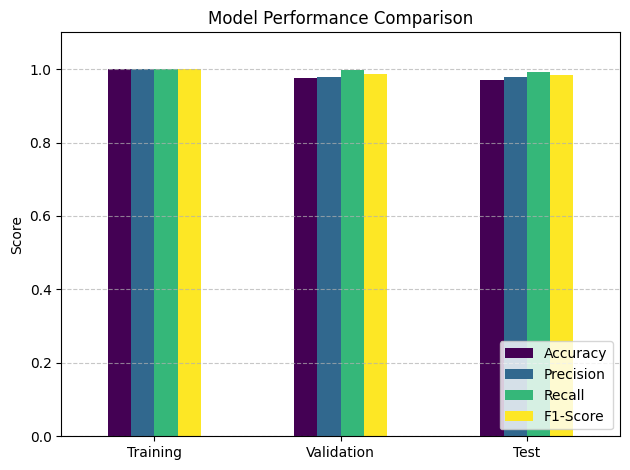

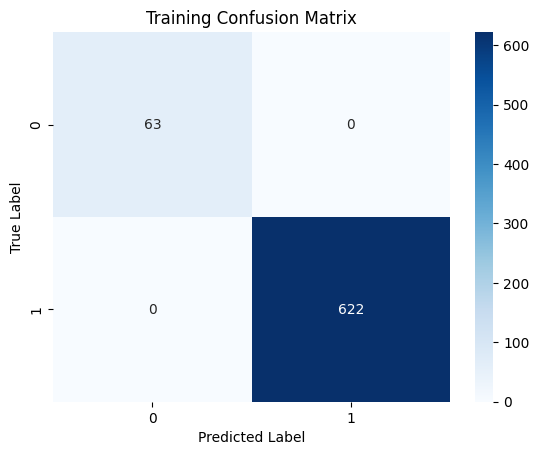

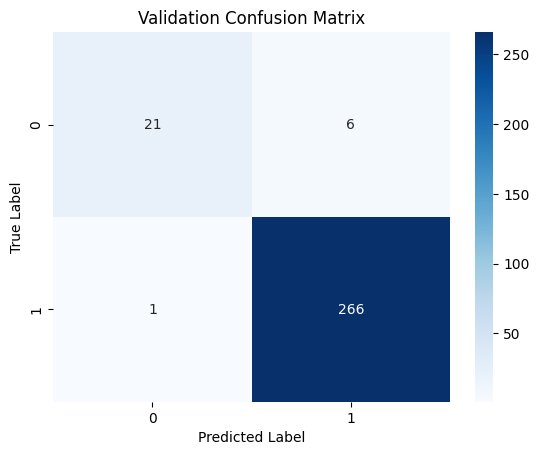

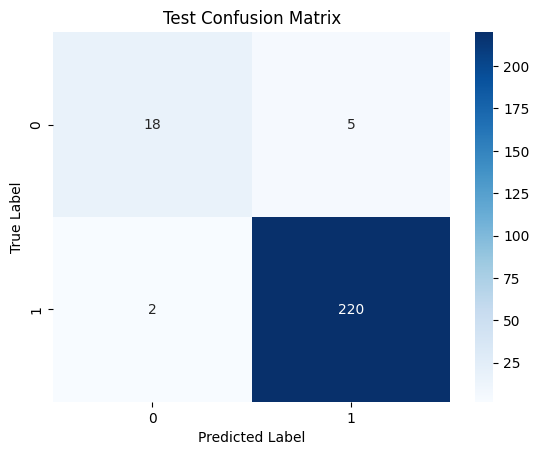

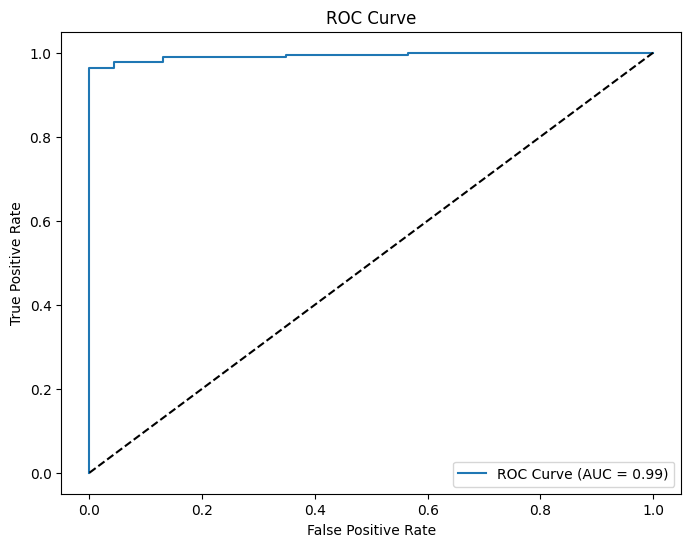

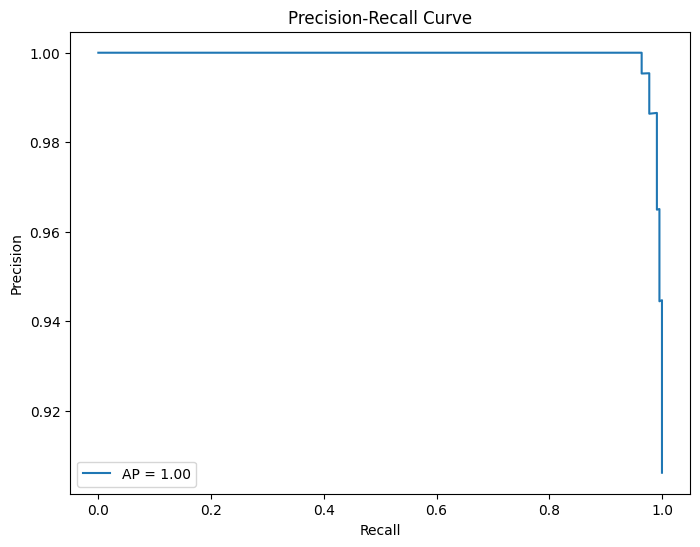

In [48]:
# CORRECTED Visualization Code with Proper Label Handling

# First, check your actual class labels
print("Unique class labels:", np.unique(y_test))

# Convert string labels to binary if needed (Tumor=1, Normal=0)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_split)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

# 1. Performance Metrics Comparison (using encoded labels)
metrics_train = {
    'Accuracy': accuracy_score(y_train_encoded, y_train_pred),
    'Precision': precision_score(y_train_encoded, y_train_pred),
    'Recall': recall_score(y_train_encoded, y_train_pred),
    'F1-Score': f1_score(y_train_encoded, y_train_pred)
}

metrics_val = {
    'Accuracy': accuracy_score(y_val_encoded, y_val_pred),
    'Precision': precision_score(y_val_encoded, y_val_pred),
    'Recall': recall_score(y_val_encoded, y_val_pred),
    'F1-Score': f1_score(y_val_encoded, y_val_pred)
}

metrics_test = {
    'Accuracy': accuracy_score(y_test_encoded, y_test_pred),
    'Precision': precision_score(y_test_encoded, y_test_pred),
    'Recall': recall_score(y_test_encoded, y_test_pred),
    'F1-Score': f1_score(y_test_encoded, y_test_pred)
}

# Create comparison plot
metrics_df = pd.DataFrame({
    'Training': metrics_train,
    'Validation': metrics_val,
    'Test': metrics_test
}).T

plt.figure(figsize=(10, 6))
metrics_df.plot(kind='bar', rot=0, colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Confusion Matrices (using original string labels)
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_conf_matrix(y_train_split, y_train_pred, "Training Confusion Matrix")
plot_conf_matrix(y_val, y_val_pred, "Validation Confusion Matrix")
plot_conf_matrix(y_test, y_test_pred, "Test Confusion Matrix")

# 3. ROC Curve (using encoded labels)
y_test_prob = model.predict_proba(X_test_pca)[:, 1]  # Probability of class 1 (Tumor)

fpr, tpr, _ = roc_curve(y_test_encoded, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 4. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_encoded, y_test_prob)
avg_precision = average_precision_score(y_test_encoded, y_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'AP = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

Unique class labels in y_test: [0 1]


<Figure size 1000x600 with 0 Axes>

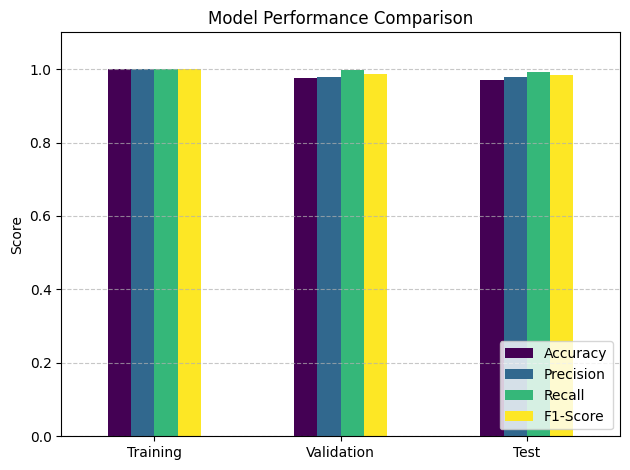

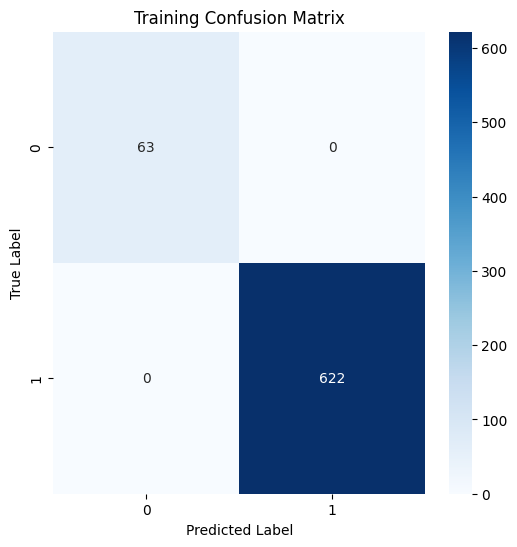

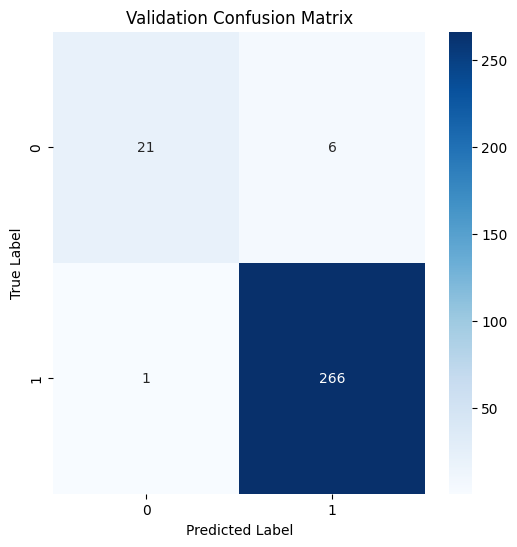

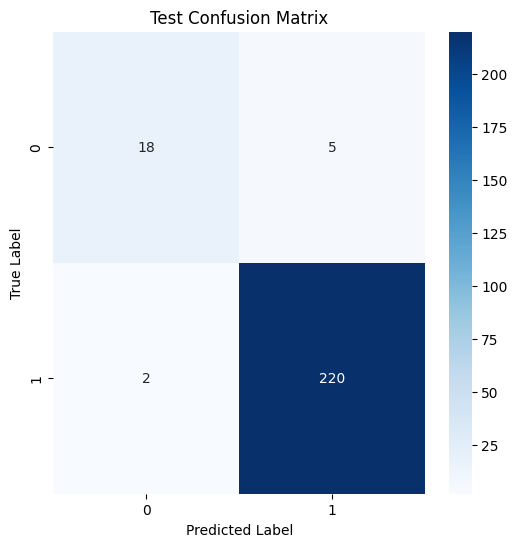

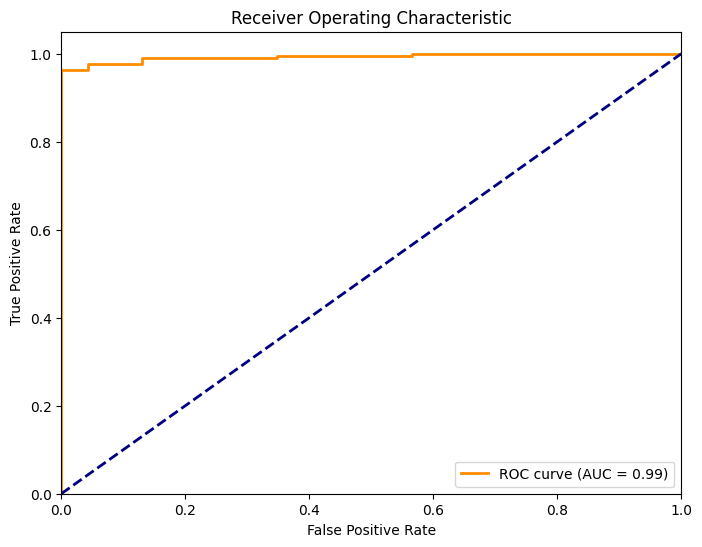

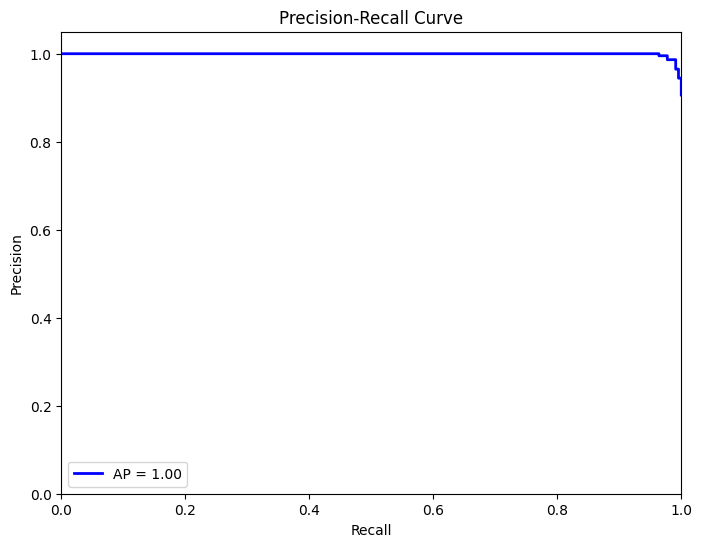

In [47]:
# COMPLETE CORRECTED VISUALIZATION CODE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, confusion_matrix, roc_curve, auc,
                           precision_recall_curve, average_precision_score)
from sklearn.preprocessing import LabelEncoder

# 1. First check your class labels
print("Unique class labels in y_test:", np.unique(y_test))

# 2. Encode string labels to numeric (if needed)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_split)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

# Get predictions (ensure these are generated)
y_train_pred = model.predict(X_train_pca_split)
y_val_pred = model.predict(X_val_pca)
y_test_pred = model.predict(X_test_pca)

# 3. Performance Metrics Comparison
def calculate_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

metrics_df = pd.DataFrame({
    'Training': calculate_metrics(y_train_encoded, y_train_pred),
    'Validation': calculate_metrics(y_val_encoded, y_val_pred),
    'Test': calculate_metrics(y_test_encoded, y_test_pred)
}).T

plt.figure(figsize=(10, 6))
metrics_df.plot(kind='bar', rot=0, colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Confusion Matrices
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_confusion_matrix(y_train_split, y_train_pred, "Training Confusion Matrix")
plot_confusion_matrix(y_val, y_val_pred, "Validation Confusion Matrix")
plot_confusion_matrix(y_test, y_test_pred, "Test Confusion Matrix")

# 5. ROC Curve
y_test_prob = model.predict_proba(X_test_pca)[:, 1]  # Probabilities for positive class
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_test_prob)
roc_auc = auc(fpr, tpr)  # Now properly defined

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# 6. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_encoded, y_test_prob)
avg_precision = average_precision_score(y_test_encoded, y_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2,
         label=f'AP = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()